<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B08%5D%20-%20NLP/nlp_tweets_publico_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP aplicado a negocio con un dataset público de X/Twitter  
## Análisis de sentimiento sobre tweets de aerolíneas

Este notebook sirve como **introducción completa y práctica al flujo de trabajo típico en NLP clásico** usando un dataset **real y público** de mensajes publicados en X sobre aerolíneas de EE. UU.

La idea no es solo entrenar un modelo, sino recorrer el flujo completo:

1. Cargar un dataset real.
2. Entender qué problema de negocio estamos resolviendo.
3. Explorar los datos.
4. Limpiar el texto.
5. Convertir texto en variables numéricas.
6. Entrenar varios modelos de clasificación.
7. Evaluar resultados.
8. Interpretar qué ha aprendido el modelo.
9. Conectar el ejercicio con casos reales de negocio.

> **Caso de negocio**: una empresa quiere monitorizar automáticamente mensajes de clientes en redes sociales para detectar si el sentimiento es positivo, neutral o negativo, y así priorizar incidencias, medir reputación y alimentar dashboards o flujos de atención al cliente.

## 1. Objetivos del notebook

Al finalizar este notebook deberías tener clara una visión bastante completa de:

- cómo se estructura un problema de NLP en clasificación de texto,
- por qué el texto no puede entrar "tal cual" a un modelo clásico,
- cómo funciona una representación **TF-IDF**,
- cómo evaluar un clasificador de texto,
- cómo interpretar resultados y errores,
- y dónde encaja esto dentro de un caso de negocio real.


## 2. Dataset público que vamos a utilizar

Usaremos el dataset **Twitter US Airline Sentiment**, muy conocido en NLP introductorio.

Contiene tweets reales dirigidos a aerolíneas como:

- United
- American
- Delta
- Southwest
- US Airways
- Virgin America

Y para cada tweet tenemos una etiqueta de sentimiento:

- `positive`
- `neutral`
- `negative`

Esto lo convierte en un ejemplo muy bueno de negocio para:

- social listening,
- customer support,
- reputación de marca,
- análisis de voz del cliente,
- detección temprana de incidencias.

En este notebook cargaremos una copia pública accesible vía URL.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

## 3. Carga de datos

Vamos a descargar el dataset desde mi Github

In [4]:
DATA_URL = "https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/refs/heads/main/%5B08%5D%20-%20NLP/Tweets.csv"

df = pd.read_csv(DATA_URL)
print("Shape:", df.shape)
df.head()

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 4. Primera inspección del dataset

Antes de modelar, toca mirar qué tenemos entre manos.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [6]:
df.columns.tolist()

['tweet_id',
 'airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'airline_sentiment_gold',
 'name',
 'negativereason_gold',
 'retweet_count',
 'text',
 'tweet_coord',
 'tweet_created',
 'tweet_location',
 'user_timezone']

Nos vamos a quedar con un subconjunto útil de variables para este ejercicio:

- `text`: contenido del tweet
- `airline_sentiment`: etiqueta objetivo
- `airline`: aerolínea mencionada
- `negativereason`: motivo del sentimiento negativo cuando aplica
- `tweet_created`: fecha/hora del tweet

In [7]:
cols = ["text", "airline_sentiment", "airline", "negativereason", "tweet_created"]
df = df[cols].copy()

print(df.shape)
df.head()

(14640, 5)


,text,airline_sentiment,airline,negativereason,tweet_created
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America,NaN,2015-02-24 11:35:52 -0800
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America,NaN,2015-02-24 11:15:59 -0800
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America,NaN,2015-02-24 11:15:48 -0800
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America,Bad Flight,2015-02-24 11:15:36 -0800
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America,Can't Tell,2015-02-24 11:14:45 -0800


## 5. Revisión básica de calidad de datos

In [8]:
df.isna().sum()

,0
text,0
airline_sentiment,0
airline,0
negativereason,5462
tweet_created,0


In [9]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


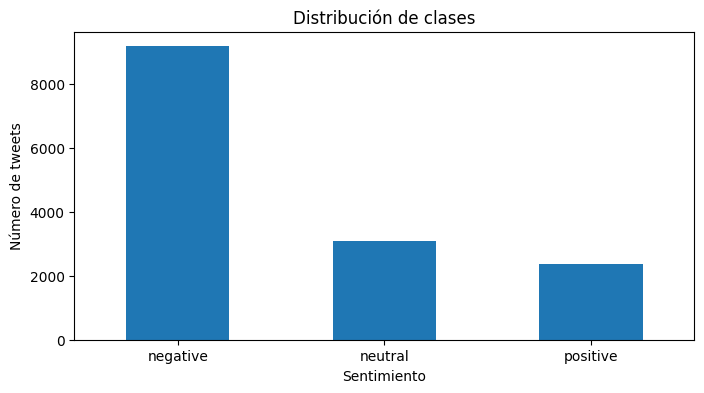

In [10]:
sentiment_counts = df["airline_sentiment"].value_counts()

plt.figure(figsize=(8, 4))
sentiment_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Sentimiento")
plt.ylabel("Número de tweets")
plt.xticks(rotation=0)
plt.show()

### Lectura rápida de negocio

Ya vemos algo importante: el dataset está **desbalanceado**.  
Hay bastantes más tweets negativos que positivos.

Esto no es raro en atención al cliente. La gente suele entrar a redes a decir:

- que algo no funciona,
- que un vuelo se retrasó,
- que perdió una conexión,
- que el servicio fue malo.

Moraleja: si el modelo va "muy bien", cuidado. A veces solo está aprendiendo a predecir la clase mayoritaria.

## 6. Exploración de ejemplos reales

Vamos a leer algunos tweets reales para aterrizar el problema.

In [11]:
pd.set_option("display.max_colwidth", 300)

df.sample(10, random_state=42)[["airline_sentiment", "airline", "text"]]

,airline_sentiment,airline,text
4794,positive,Southwest,@SouthwestAir you're my early frontrunner for best airline! #oscars2016
10480,negative,US Airways,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?
8067,negative,Delta,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?
8880,neutral,Delta,"@JetBlue do they have to depart from Washington, D.C.??"
8292,negative,Delta,@JetBlue I can probably find some of them. Are the ticket #s on there?
927,negative,United,@united still waiting to hear back. My wallet was stolen from one of your planes so would appreciate a resolution here
3165,negative,United,@united Yes my flight was rebooked. I'm just losing trust in you if I want to get anywhere on time.
7894,neutral,Delta,@JetBlue Thank you ! What about Paris ? Could we arrange something from there ?
2818,negative,United,"@united not 100% sure, however my ticket included one checked bag, therefore this charge was extra and completely unanticipated."
9145,positive,US Airways,"@usairways great crew for flight 504 PHX to YVR tonight! Friendly, efficient. Awesome job."


In [12]:
for sentiment in ["negative", "neutral", "positive"]:
    print("=" * 90)
    print(f"EJEMPLOS DE LA CLASE: {sentiment.upper()}")
    print("=" * 90)
    examples = df[df["airline_sentiment"] == sentiment]["text"].sample(3, random_state=42)
    for i, txt in enumerate(examples, 1):
        print(f"{i}. {txt}")
    print()

EJEMPLOS DE LA CLASE: NEGATIVE
1. @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi
2. @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.
3. @united installed and working are not the same. Kicked me out after an hour and wouldn't let me back in. Four wasted hours.

EJEMPLOS DE LA CLASE: NEUTRAL
1. @united we finally just arrive to Bogota, good but long flight!!
2. @AmericanAir got a callback at 1 am, took care of it. thanks.
3. @JetBlue is there wifi on he plain

EJEMPLOS DE LA CLASE: POSITIVE
1. @SouthwestAir thanks for your excellent response time and assistance! All set :)
2. @JetBlue thanks. I appreciate your prompt response.
3. @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!



## 7. Longitud de los textos

Antes de limpiar y vectorizar, suele ser útil ver cómo de largos son los textos.

In [13]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

df[["text_len", "word_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
text_len,14640.0,103.822063,36.277339,12.0,77.0,114.0,136.0,186.0
word_count,14640.0,17.653415,6.882259,2.0,12.0,19.0,23.0,36.0


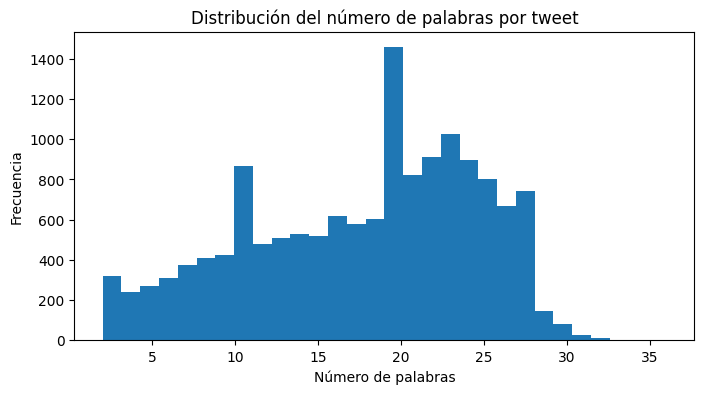

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(df["word_count"], bins=30)
plt.title("Distribución del número de palabras por tweet")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

In [15]:
df.groupby("airline_sentiment")[["text_len", "word_count"]].mean().round(2)

,text_len,word_count
airline_sentiment,,
negative,113.95,19.69
neutral,87.36,14.41
positive,86.08,14.01


Esto nos da contexto: estamos ante textos **cortos**, algo muy típico en soporte, reviews, chats o redes sociales.

Eso hace que técnicas simples como **TF-IDF + modelo lineal** funcionen sorprendentemente bien muchas veces.

## 8. Preparación del texto

En NLP clásico, una parte clave del trabajo es la **limpieza** del texto.

No existe una limpieza universal perfecta. Depende del caso de negocio.

Aquí haremos una versión razonable para este problema:

- pasar a minúsculas,
- eliminar URLs,
- eliminar menciones (`@usuario`),
- quitar símbolos extraños,
- normalizar espacios.

No eliminaremos stopwords en esta primera versión, porque a veces en sentimiento ciertas palabras funcionales ayudan más de lo que parecen.

In [17]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)     # URLs
    text = re.sub(r"@\w+", " ", text)               # menciones
    text = re.sub(r"#", " ", text)                   # quitamos solo el símbolo #
    text = re.sub(r"[^a-z\s]", " ", text)           # dejamos letras y espacios
    text = re.sub(r"\s+", " ", text).strip()        # espacios extra
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].sample(8, random_state=42)

,text,clean_text
4794,@SouthwestAir you're my early frontrunner for best airline! #oscars2016,you re my early frontrunner for best airline oscars
10480,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?,how is it that my flt to ewr was cancelled flightled yet flts to nyc from usairways are still flying
8067,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?,what is going on with your bdl to dca flights yesterday and today why is every single one getting delayed
8880,"@JetBlue do they have to depart from Washington, D.C.??",do they have to depart from washington d c
8292,@JetBlue I can probably find some of them. Are the ticket #s on there?,i can probably find some of them are the ticket s on there
927,@united still waiting to hear back. My wallet was stolen from one of your planes so would appreciate a resolution here,still waiting to hear back my wallet was stolen from one of your planes so would appreciate a resolution here
3165,@united Yes my flight was rebooked. I'm just losing trust in you if I want to get anywhere on time.,yes my flight was rebooked i m just losing trust in you if i want to get anywhere on time
7894,@JetBlue Thank you ! What about Paris ? Could we arrange something from there ?,thank you what about paris could we arrange something from there


### Comparativa rápida antes / después

In [18]:
for original, cleaned in df[["text", "clean_text"]].sample(5, random_state=7).values:
    print("ORIGINAL :", original)
    print("LIMPIO   :", cleaned)
    print("-" * 120)

ORIGINAL : @united you've been officially displaced by @DeltaAssist for better flight experience, pleasant cabin crew and timeliness. UA 1m switching!
LIMPIO   : you ve been officially displaced by for better flight experience pleasant cabin crew and timeliness ua m switching
------------------------------------------------------------------------------------------------------------------------
ORIGINAL : @united Are the current on board food menus available anywhere online?
LIMPIO   : are the current on board food menus available anywhere online
------------------------------------------------------------------------------------------------------------------------
ORIGINAL : @AmericanAir yes. Shows Cancelled Flightled &amp; asks for her to contact you at 800 number.
LIMPIO   : yes shows cancelled flightled amp asks for her to contact you at number
------------------------------------------------------------------------------------------------------------------------
ORIGINAL : @JetBlu

## 9. Definición del problema de ML

Estamos ante un problema de **clasificación multiclase**:

**Input**: el texto del tweet  
**Output**: una etiqueta entre:

- `negative`
- `neutral`
- `positive`

### Variable objetivo

In [19]:
X = df["clean_text"]
y = df["airline_sentiment"]

print("Número de muestras:", len(X))
print("Clases:", sorted(y.unique()))

Número de muestras: 14640
Clases: ['negative', 'neutral', 'positive']


## 10. Train / test split

Separamos train y test para poder evaluar el modelo sobre datos no vistos.

Usamos `stratify=y` para mantener proporciones similares de clases en ambos conjuntos.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape[0])
print("Test :", X_test.shape[0])

print("\nDistribución en train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución en test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 11712
Test : 2928

Distribución en train:
airline_sentiment
negative    0.627
neutral     0.212
positive    0.161
Name: proportion, dtype: float64

Distribución en test:
airline_sentiment
negative    0.627
neutral     0.212
positive    0.162
Name: proportion, dtype: float64


## 11. Baseline tonto pero obligatorio

Antes de entrenar TF-IDF y modelos más serios, montamos un **baseline** con `DummyClassifier`.

Esto es higiene básica de ML.

Si nuestro modelo "bueno" no mejora a un clasificador tonto, tenemos un problema serio.

In [21]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Accuracy baseline:", round(accuracy_score(y_test, dummy_pred), 4))
print("F1 macro baseline:", round(f1_score(y_test, dummy_pred, average="macro"), 4))
print()
print(classification_report(y_test, dummy_pred))

Accuracy baseline: 0.6267
F1 macro baseline: 0.2568

              precision    recall  f1-score   support

    negative       0.63      1.00      0.77      1835
     neutral       0.00      0.00      0.00       620
    positive       0.00      0.00      0.00       473

    accuracy                           0.63      2928
   macro avg       0.21      0.33      0.26      2928
weighted avg       0.39      0.63      0.48      2928



## 12. Primer pipeline: TF-IDF + Logistic Regression

Este es uno de los clásicos del NLP tabularizado. Muy duro, muy fiable y nada complejo.

### Recordatorio conceptual

`TfidfVectorizer` convierte texto en una matriz numérica donde cada columna representa un término, ponderado por su relevancia relativa.

Después, `LogisticRegression` aprende fronteras para clasificar los textos.

In [22]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logreg_pipeline.fit(X_train, y_train)
logreg_pred = logreg_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, logreg_pred), 4))
print("F1 macro:", round(f1_score(y_test, logreg_pred, average="macro"), 4))
print()
print(classification_report(y_test, logreg_pred))

Accuracy: 0.7804
F1 macro: 0.737

              precision    recall  f1-score   support

    negative       0.89      0.82      0.85      1835
     neutral       0.57      0.72      0.63       620
    positive       0.73      0.71      0.72       473

    accuracy                           0.78      2928
   macro avg       0.73      0.75      0.74      2928
weighted avg       0.80      0.78      0.79      2928



## 13. Matriz de confusión del modelo LogReg

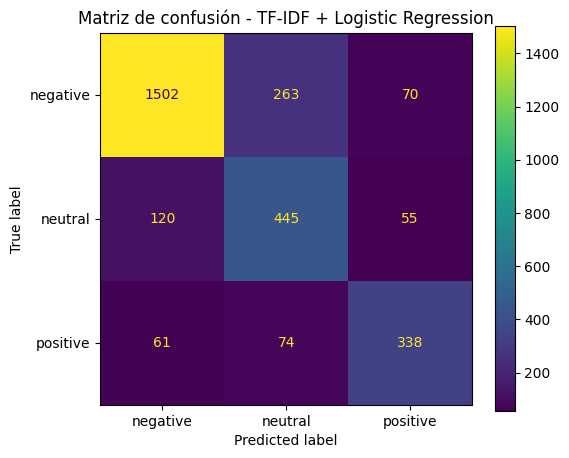

In [23]:
cm = confusion_matrix(y_test, logreg_pred, labels=logreg_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_pipeline.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
plt.title("Matriz de confusión - TF-IDF + Logistic Regression")
plt.show()

## 14. Segundo pipeline: TF-IDF + Linear SVC

Otro clásico del NLP con texto disperso (`sparse data`).

Los modelos lineales suelen funcionar muy bien en clasificación de texto cuando tenemos representaciones tipo bolsa de palabras / TF-IDF.

In [24]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95
    )),
    ("model", LinearSVC(class_weight="balanced"))
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, svm_pred), 4))
print("F1 macro:", round(f1_score(y_test, svm_pred, average="macro"), 4))
print()
print(classification_report(y_test, svm_pred))

Accuracy: 0.7889
F1 macro: 0.7328

              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      1835
     neutral       0.60      0.67      0.63       620
    positive       0.75      0.66      0.70       473

    accuracy                           0.79      2928
   macro avg       0.74      0.73      0.73      2928
weighted avg       0.79      0.79      0.79      2928



## 15. Comparativa de modelos

In [25]:
results = pd.DataFrame({
    "modelo": ["Dummy most_frequent", "TF-IDF + LogisticRegression", "TF-IDF + LinearSVC"],
    "accuracy": [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, logreg_pred),
        accuracy_score(y_test, svm_pred),
    ],
    "f1_macro": [
        f1_score(y_test, dummy_pred, average="macro"),
        f1_score(y_test, logreg_pred, average="macro"),
        f1_score(y_test, svm_pred, average="macro"),
    ]
}).sort_values(by="f1_macro", ascending=False)

results.round(4)

,modelo,accuracy,f1_macro
1,TF-IDF + LogisticRegression,0.7804,0.7370
2,TF-IDF + LinearSVC,0.7889,0.7328
0,Dummy most_frequent,0.6267,0.2568


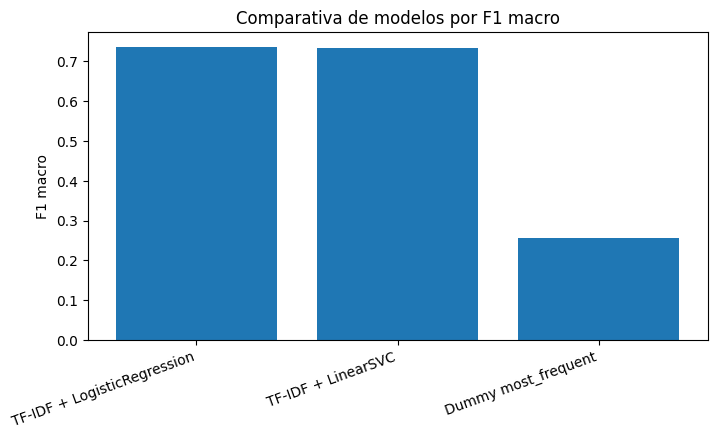

In [26]:
plt.figure(figsize=(8, 4))
plt.bar(results["modelo"], results["f1_macro"])
plt.title("Comparativa de modelos por F1 macro")
plt.ylabel("F1 macro")
plt.xticks(rotation=20, ha="right")
plt.show()

### Conclusión intermedia

Sin hacer nada exótico ya tenemos un pipeline bastante serio:

- dataset real,
- limpieza,
- vectorización,
- entrenamiento,
- evaluación,
- comparación de modelos.


## 16. Interpretabilidad: palabras más influyentes por clase

Una ventaja de modelos lineales sobre TF-IDF es que podemos inspeccionar qué términos están empujando a cada clase.

Eso da **explicabilidad** y ayuda mucho al negocio.

Vamos a hacerlo con la regresión logística.

In [27]:
tfidf = logreg_pipeline.named_steps["tfidf"]
model = logreg_pipeline.named_steps["model"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = model.classes_

for i, class_name in enumerate(classes):
    top_pos = np.argsort(model.coef_[i])[-15:][::-1]
    print("=" * 100)
    print(f"PALABRAS / N-GRAMAS MÁS ASOCIADOS A LA CLASE: {class_name.upper()}")
    print("=" * 100)
    print(feature_names[top_pos])
    print()

PALABRAS / N-GRAMAS MÁS ASOCIADOS A LA CLASE: NEGATIVE
['not' 'no' 'delayed' 'hours' 'worst' 'your' 'hour' 'cancelled' 'delay'
 'nothing' 'hrs' 'on hold' 'why' 'again' 'hold']

PALABRAS / N-GRAMAS MÁS ASOCIADOS A LA CLASE: NEUTRAL
['is there' 'can you' 'hi' 'do you' 'is your' 'destinationdragons' 'need'
 'any' 'can' 'do' 'dm' 'or' 'avgeek' 'flyingitforward' 'if']

PALABRAS / N-GRAMAS MÁS ASOCIADOS A LA CLASE: POSITIVE
['great' 'thanks' 'awesome' 'love' 'amazing' 'thank' 'thx' 'thank you'
 'best' 'the best' 'appreciate' 'good' 'thanks for' 'excellent'
 'wonderful']



### Lectura de negocio

Aquí suelen aparecer cosas como:

- retrasos,
- cancelaciones,
- thanks,
- great,
- delayed,
- customer service,
- hours,
- hold,
- lost baggage...

Esto ya se parece mucho a una **herramienta básica de social listening**.

## 17. Análisis de errores

Un modelo no se entiende de verdad hasta que vemos **en qué falla**.

Vamos a revisar algunos casos donde el mejor modelo se equivoca.

In [28]:
best_model_name = results.iloc[0]["modelo"]
best_pred = svm_pred if best_model_name == "TF-IDF + LinearSVC" else logreg_pred

errors_df = pd.DataFrame({
    "text": X_test.values,
    "real": y_test.values,
    "pred": best_pred
})

errors_df = errors_df[errors_df["real"] != errors_df["pred"]].copy()
print("Número de errores:", errors_df.shape[0])

errors_df.sample(min(12, len(errors_df)), random_state=42)

Número de errores: 643


,text,real,pred
2869,yes tells me the only way to mod plans is to call the number,neutral,negative
1709,was far less painful than what was coming from avis,positive,negative
2269,i love imagine dragons o flipping much pls destinationdragons,positive,neutral
1361,okay if someone does it look for it now my fear is it will be lost forever it s a very small item,negative,neutral
356,that is great but once it gets to buffalo will it be able to leave and get to jfk or there s issues still at buffalo airport,positive,negative
2071,when can we expect customer service in dallas to be available,neutral,negative
2735,stuck in cae need reflight booking problems for next flight possibly dm for more info,negative,neutral
1822,coach interior on ua looked like it was salvaged from the s tiny unusable video no power amp lifevests on the floor ua,negative,neutral
2809,thanks for your help got me what i need but its an issue with i guess i sit awhile longer,positive,negative
813,i hope so because i fly very often and would hate to change airlines,neutral,negative


### Busca patrones como estos:

- ironía o sarcasmo,
- contexto insuficiente,
- texto muy corto,
- ambigüedad,
- mezcla de queja + agradecimiento,
- problemas de limpieza,
- expresiones raras o abreviadas.


## 18. Predicciones sobre mensajes nuevos

Ahora probamos el modelo con tweets / mensajes nuevos inventados por nosotros.

In [29]:
examples = [
    "thanks delta for the amazing flight and friendly staff",
    "my flight is delayed again and nobody is answering me",
    "i have a question about my baggage allowance",
    "still waiting at the airport for more information",
    "best airline experience in months"
]

best_pipeline = svm_pipeline if best_model_name == "TF-IDF + LinearSVC" else logreg_pipeline
preds = best_pipeline.predict(examples)

pd.DataFrame({
    "mensaje": examples,
    "prediccion": preds
})

,mensaje,prediccion
0,thanks delta for the amazing flight and friendly staff,positive
1,my flight is delayed again and nobody is answering me,negative
2,i have a question about my baggage allowance,neutral
3,still waiting at the airport for more information,negative
4,best airline experience in months,positive


### Posible uso en negocio

A partir de aquí podrías añadir fácilmente:

- una columna de prioridad,
- una regla de escalado,
- un dashboard en Power BI / Looker / Tableau,
- un flujo automático con email, ticketing o CRM.

Y aquí es justo donde enlaza muy bien el salto posterior a **LLMs + automatización + agentes**.

## 20. Limitaciones del enfoque clásico

Muy importante: esto funciona, sí. Pero tiene limitaciones.

### Limitaciones principales

1. **Necesitas datos etiquetados**
   - alguien tuvo que marcar tweets como positivos, negativos o neutrales.

2. **Generaliza peor fuera del dominio**
   - si entrenas con aerolíneas y luego lo pasas a banca o e-commerce, puede sufrir.

3. **Entiende poco el contexto profundo**
   - sarcasmo, ironía, dobles sentidos... mal asunto.

4. **Cambios en el lenguaje**
   - abreviaturas, modas, nuevos términos, etc.

5. **No razona**
   - clasifica por patrones estadísticos, no por "comprensión" humana.

## Conclusiones finales

### Qué nos llevamos de este notebook

Hemos recorrido un flujo bastante completo de NLP:

- dataset público real,
- comprensión del problema,
- EDA,
- limpieza,
- representación TF-IDF,
- baseline,
- modelos lineales,
- evaluación,
- interpretabilidad,
- análisis de errores,
- conexión con negocio.
